# CPO for QAR

## Definizione degli input

In [25]:
from dataclasses import dataclass
import polars as pl

@dataclass(frozen=True)
class Interval:
    label: str
    begin: int
    end: int

A_i = Interval("CO", 0, 1)

df = pl.DataFrame({"CO": [0, 1, 1, 2, 3, 3], "OO": [5, 4, 3, 2, 1, 0], "NOX": [1, 1, 1, 2, 3, 0]})

df

CO,OO,NOX
i64,i64,i64
0,5,1
1,4,1
1,3,1
2,2,2
3,1,3
3,0,0


## Generazione di intervalli

 Given an instance of a quantitative dataset d on the schema $ A_1,...,A_n,C$ , we denote by $\mathbb{T}$ any set of tests over d. We define $\mathbb{T}_{i/}$ as the set of all possible tests on d excluding those on attribute $A_i$.  
 Formally:
\begin{align}
\mathbb{T}_{i/} = \{ A_j \bowtie n \mid j \neq i, \bowtie \in \{\leq, \geq\}, k \in \mathbb{N} \}
\end{align}

Given a set of tests $T ⊆ \mathbb{T}_{i/}$, we say that it entails
 an interval [b,e] on the attribute Aj, written as
 $T → A_j[b,e]$, if and only if one of the following
 conditions holds:
 1. b = 0 and there exists $A_j ≤ e ∈ T$ and for all
 lower tests $A_j ≥ k ∈ T$, we have k > e
 2. b= 0 and there exists a lower test $A_j ≥ b ∈
 T$, and e is the minimum value e > b such
 that $A_j ≤ e ∈T$
 3. b= 0 and there exists a lower test $A_j ≥ b ∈
 T$, and for all upper tests $A_j ≤ k ∈ T$, we
 have b > k, and e = maxj

From now on, we refer to the notation $A_j[b,e]$ as
 a labelled interval.
 We denote by AI the set of all labelled intervals
 on dataset d. Formally:  
 \begin{align}
 AI = \{ A_j[b,e] | 1 ≤ j ≤ n,[b,e] ∈ IN \}
 \end{align}

In [26]:
from typing import List, Set

@dataclass(frozen=True)
class Test:
  label: str
  op: str
  value: int

def get_labelled_intervals(tests: Set[Test]) -> Set[Interval]:
  AI = []
  for test in tests:
      if test.op == '<=':
          wit = list(filter(lambda x: x.op == '>=' and x.label == test.label and x.value <=  test.value, tests))
          if len(wit) == 0:
              AI.append(Interval(test.label, min(df[test.label]), test.value))
          else:
              AI.append(Interval(test.label,max(wit, key=lambda x: x.value).value, test.value))
      else:
          wit = list(filter(lambda x: x.op == '<=' and x.label == test.label and x.value >=  test.value, tests))
          if len(wit) == 0:
              AI.append(Interval(test.label, test.value, max(df[test.label]) ))
          else:
              AI.append(Interval(test.label,test.value, min(wit, key=lambda x: x.value).value))

  return set(AI)

def test_labelled_intervals():
  T = {Test("OO", "<=", 1), Test("CO", "<=", 2), Test("OO", ">=", 2), Test("OO", "<=", 3), Test("OO", ">=", 4)}

  expected_out = {Interval('OO', 0, 1), Interval('OO', 2, 3), Interval('OO', 4, 5), Interval("CO", 0, 2)}

  assert get_labelled_intervals(T) == expected_out, "Error in get_labelled_intervals"

test_labelled_intervals()

## Supporto per intervalli

Given a set of labelled intervals AI ⊆ AI, we
 say that a tuple t satisfies AI (written as $t \models \mathit{AI}$ )
 if and only if:  
\begin{align}
t \models \mathit{AI} \iff \forall i \in \{1, \ldots, n\} : \big(\nexists A_i[b,e] \in \mathit{AI}\big) \lor \big(\exists A_i[b,e] \in \mathit{AI} : b \leq t[A_i] \leq e\big)
\end{align}

 Given a set of labelled intervals AI ⊆ AI, its
 support in dataset instance d is defined as:  

\begin{align}
support(AI, d) = \frac{\sum_{t\in d : t \models AI} t[C]}{ \sum_{t\in d} t[C]}
\end{align}

In [27]:
from collections import defaultdict

def make_AI_expr(AI) -> pl.Expr:
    d = defaultdict(list)
    for item in AI:
        d[item.label].append(item)

    final_expr = pl.lit(True)
    for label, intervals in d.items():
        label_expr = pl.lit(False)
        for interval in intervals:
            label_expr |= pl.col(label).is_between(interval.begin, interval.end)

        final_expr &= label_expr

    return final_expr

def get_support(AI: Set[Interval]):
  return len(df.filter(make_AI_expr(AI))) / len(df)

def test_get_support():
  AI_test = {Interval("OO", 0, 2)}

  assert get_support(AI_test) == 0.5, "Error in support calculation"

test_get_support()

## CPO e j-measure

\begin{align}
J(X \to Y) = p(X) \cdot \left( p(Y|X) \log_2 \left( \frac{p(Y|X)}{p(Y)} \right) + \left(1 - p(Y|X)\right) \log_2 \left( \frac{1 - p(Y|X)}{1 - p(Y)} \right) \right)
\end{align}

In [28]:
import numpy as np

def j_measure(X, Y):
  p_X = get_support(X)
  if p_X == 0:
    return 0

  p_Y = get_support(Y)
  p_YX = get_support(X | Y) / p_X

  res = 0

  if p_YX != 0:
    res += (p_YX * np.log2(p_YX / p_Y))

  if p_YX != 1:
    res += (1-p_YX) * np.log2((1 - p_YX) / (1 - p_Y))

  return res * p_X

def make_cpo(A_i):
  def cpo(T_minus_i):
    X = get_labelled_intervals(T_minus_i)
    return j_measure(X, set([A_i]))

  return cpo

In [29]:
import random
from math import factorial
from tqdm import tqdm

def estimate_shapley(X, test, n_samples, cpo):
  T_i = X - set([test])

  Xrand = set()
  while len(Xrand) < n_samples:
    Xrand.update({ frozenset(random.sample(list(T_i), random.randint(1, len(T_i) - 1))) for _ in range(n_samples - len(Xrand)) })

  print("Estimating with ", len(Xrand), " samples")
  N = 0
  D = 0

  for i, Xi in enumerate(tqdm(Xrand)):
    # print(f"X{i}: ", len(Xi))
    Di = factorial(len(Xi)) * factorial(len(X) - len(Xi) - 1)
    N += Di * (cpo(Xi | {test}) - cpo(Xi))
    N += Di * (cpo(X - Xi) - cpo((X - Xi) | {test})) # calcola il duale
    D += 2 * Di

  return N / D

# Applicazione su dataset Air Quality

## Preparazione dataset

In [30]:
try:
  if dataset:
    print("Already loaded")
except:
  !pip install ucimlrepo polars
  from ucimlrepo import fetch_ucirepo
  dataset = fetch_ucirepo(id=360)

dataset.data.features

Already loaded


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,4/4/2005,10:00:00,3.1,1314,-200,13.5,1101,472,539,190,1374,1729,21.9,29.3,0.7568
9353,4/4/2005,11:00:00,2.4,1163,-200,11.4,1027,353,604,179,1264,1269,24.3,23.7,0.7119
9354,4/4/2005,12:00:00,2.4,1142,-200,12.4,1063,293,603,175,1241,1092,26.9,18.3,0.6406
9355,4/4/2005,13:00:00,2.1,1003,-200,9.5,961,235,702,156,1041,770,28.3,13.5,0.5139


In [31]:
import polars as pl

aq = pl.from_pandas(dataset.data.features)

aq = (aq
    # Drop specified columns
    .drop(["Date", "Time", "RH", "AH"])

    # Drop GT columns
    .drop(filter(lambda x: x[-4:] == '(GT)', aq.columns))

    # Rename columns
    .rename({
        'PT08.S1(CO)': 'CO',
        'PT08.S2(NMHC)': 'NMHC',
        'PT08.S3(NOx)': 'NOX',
        'PT08.S4(NO2)': 'NOO',
        'PT08.S5(O3)': 'OOO'
    })

    # Filter out rows with invalid values
    .filter(pl.any_horizontal(pl.all().ne(-200)))
)

aq

CO,NMHC,NOX,NOO,OOO,T
i64,i64,i64,i64,i64,f64
1360,1046,1056,1692,1268,13.6
1292,955,1174,1559,972,13.3
1402,939,1140,1555,1074,11.9
1376,948,1092,1584,1203,11.0
1272,836,1205,1490,1110,11.2
…,…,…,…,…,…
1314,1101,539,1374,1729,21.9
1163,1027,604,1264,1269,24.3
1142,1063,603,1241,1092,26.9


In [32]:
# Create encoders dictionary first
encoder = {
    col: sorted(aq.get_column(col).unique().to_list())
    for col in aq.columns
}

df = pl.DataFrame()

# Encode each column using match patterns
df = aq.select([
    pl.col(column).replace_strict(
        dict(zip(values, range(len(values)))), # mappa {k: valore, v: indice}
    ).alias(column)
    for column, values in encoder.items()
])

df.sort("CO")

CO,NMHC,NOX,NOO,OOO,T
i64,i64,i64,i64,i64,i64
0,11,1202,85,12,115
1,4,1209,102,7,111
2,6,1210,118,11,109
3,19,1177,95,19,116
3,37,1154,91,25,123
…,…,…,…,…,…
1036,1209,260,1543,1716,240
1037,1171,240,1544,1726,214
1038,1239,0,1574,1729,141


## CPO

In [33]:
from random import sample

# test = {Test("OOO", '>=', encoder['OOO'].index(1162))}
Y = Interval("NMHC", 1046, 2214)

# devo togliare anche le label del parametro sotto test? (tipo OOO)
A = set(df.columns) - set([Y.label])

T_all = [ Test(label, o, value ) for label in A for value in encoder[label] for o in ["<=",  ">="] ]
T = set(sample(T_all, k=170))

test = T.pop()

cpo_func = make_cpo(Y)

In [34]:
test

Test(label='NOO', op='>=', value=1905)

In [35]:
output = []

for n_samples in range(1, 171, 5):
  s_x_cpo = estimate_shapley(T, test, n_samples, cpo_func)

  output.append(s_x_cpo)

Estimating with  1  samples


100%|██████████| 1/1 [00:00<00:00, 15.96it/s]


Estimating with  6  samples


100%|██████████| 6/6 [00:00<00:00, 12.21it/s]


Estimating with  11  samples


...

100%|██████████| 156/156 [00:09<00:00, 15.76it/s]


Estimating with  161  samples


100%|██████████| 161/161 [00:09<00:00, 16.93it/s]


Estimating with  166  samples


100%|██████████| 166/166 [00:09<00:00, 17.22it/s]


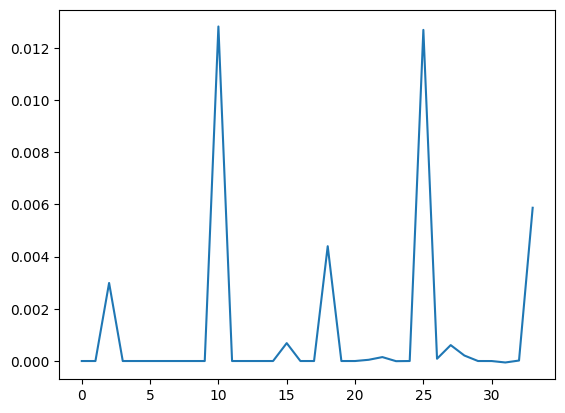

In [36]:
import matplotlib.pyplot as plt
plt.plot(output)